# Model evaluation

In this notebook, I will compare the accuracy metrics of models

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
import scienceplots  # noqa # pylint: disable=unused-import

plt.style.use(["science", "ieee", "default"])
plt.rcParams.update({"axes.grid": True})

In [4]:
from tqdm.auto import tqdm

## Prepare dataloader

In [5]:
from pathlib import Path

ROOT_DATA_DIR = Path("../data/")

In [6]:
from collections import defaultdict

import lightning.pytorch as pl
import torch
from lightning.pytorch import Trainer, seed_everything
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from torch import Tensor, nn
from torch.utils.data import DataLoader, TensorDataset

from src.utils import get_metrics

In [7]:
# torch.set_default_dtype(torch.float32)

take only 1 dataset, 1 concrete time series for now...

In [8]:
DATA_DIR = ROOT_DATA_DIR / "KPI-Anomaly-Detection/Preliminary_dataset"

In [9]:
df = pd.read_parquet(DATA_DIR / "train.parquet")
df.rename(columns={"label": "target"}, inplace=True)
df = df[df["KPI ID"] == "02e99bd4f6cfb33f"].copy()
df = df[df.index > 1.49 * 1e9].copy()
df = df.query("timestamp < 1496538120").copy()
df["time"] = df.index - df.index[0]
# df["value"] = df["value"].diff()
# df = df.query('stock==1 & day==0 & train==1')
# df.value = df.value.pct_change()
df.dropna(inplace=True)

In [10]:
def convert_to_windows(x, window_size):
    # convert input time series x to
    # time series of lags, first window_size observations are dropped
    windows = []
    for i in range(window_size, len(x)):
        w = x[i - window_size : i]
        windows.append(w)
    windows = np.array(windows)
    return windows

In [11]:
df["value_diff"] = df["value"].diff()
tr_cols = ["value", "value_diff"]
df = df.dropna()

In [12]:
# fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# plt.subplot(1, 2, 1)
# plt.plot(df.value.diff())
# plt.subplot(1, 2, 2)
# plt.hist(df.value)
# plt.yscale("log")
# plt.tight_layout();

In [13]:
window_size = 8
train_proportion = 0.9
batch_size = 16
learning_rate = 1e-5
epochs = 30

In [14]:
x = df[tr_cols].values.copy()
scaler = MinMaxScaler()
x = scaler.fit_transform(x)
# x_scaled = x
x = convert_to_windows(x, window_size)
y = df["target"].values
y = y[window_size:]

# class_weights = compute_class_weight('balanced', classes=[0, 1], y=y.ravel())
# class_weights = class_weights / class_weights.sum()

x = torch.Tensor(x).float()
y = torch.Tensor(y).float()

train_idx = int(len(x) * train_proportion)
# train_idx = int(1.495 * 1e9)

tr, va = x[:train_idx], x[train_idx:]
# x = np.hstack([x, y.reshape(-1, 1)])
# y = y.reshape(-1, 1)
ytr, yva = y[:train_idx], y[train_idx:]
tr_dataset = TensorDataset(tr, ytr)
va_dataset = TensorDataset(va, yva)

In [15]:
# fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# plt.sca(axs[0])
# plt.plot(tr[:, 0, 0])
# plt.sca(axs[1])
# plt.plot(tr[:, 0, 1])
# fig.tight_layout();

## Evaluate models

In [16]:
from src.utils import MetricTracker

In [17]:
from src.transformer import TransformerAnomalyDetector, TransformerEncoder

### Scaled Dot-Product

In [18]:
window_size = 8
train_proportion = 0.9
batch_size = 2 * 4096
epochs = 100

In [19]:
seed_everything(1)

tr_dl = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)
va_dl = DataLoader(va_dataset, batch_size=batch_size, shuffle=False)

Global seed set to 1


> **TODO**: add positional enocding

In [20]:
seed_everything(1)

input_dim = len(tr_cols)

block_args = {
    "input_dim": 8,
    "num_heads": 2,
    "dim_feedforward": 2 * 8,
    "num_layers": 1,
    "enable_layer_norm": False,
}
positional_encoder_args = {
    "enable": False,
    "max_len": window_size,
}

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5))

model_params = {
    "input_dim": input_dim,
    "block_input_dim": block_args["input_dim"],
    "block_args": block_args,
    "num_layers": block_args["num_layers"],
    "positional_encoder_args": positional_encoder_args,
    "learning_rate": 1e-1,
    "dropout": 0.0,
    "loss_fn": loss_fn,
}


model = TransformerAnomalyDetector(
    **model_params,
)

Global seed set to 1
positional encoding disabled
layer norm disabled


In [21]:
# https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.LearningRateFinder.html#learningratefinder

from lightning.pytorch.callbacks import LearningRateFinder

In [22]:
seed_everything(1)
trainer = pl.Trainer(
    max_epochs=epochs,
    log_every_n_steps=1,
    callbacks=[LearningRateFinder(), MetricTracker()],
)

trainer.fit(model, tr_dl, va_dl)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 99 steps due to diverging loss.
Learning rate set to 7.585775750291837e-08
Restoring states from the checkpoint path at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_4c5eda87-afb9-4a78-938b-690f1744ae69.ckpt
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_4c5eda87-afb9-4a78-938b-690f1744ae69.ckpt

  | Name                | Type               | Params
-----------------------------------------------------------
0 | front_linear        | Linear             | 24    
1 | positional_encoder  | Identity           | 0     
2 | transformer_encoder | TransformerEncoder | 544   
3 | final_linear        | Linear             | 9     
4 | loss_fn             | BCEWithLogitsLoss  | 0     
-----------------------------------------------------------
577       Trainable params
0         Non-trainable params
577       Total params
0.002     Total estimated model params size (MB)
Restored all s

Sanity Checking: 0it [00:00, ?it/s]

/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [23]:
# %reload_ext tensorboard
# %tensorboard --logdir=lightning_logs/

In [24]:
mt = trainer.callbacks[1]

In [25]:
from copy import deepcopy
res = deepcopy(mt.collection)
for r in res:
    for k, v in r.items():
        if type(v) == torch.Tensor:
            r[k] = np.float32(v.cpu())
        else:
            r[k] = np.float32(v)
res = pd.DataFrame(res)

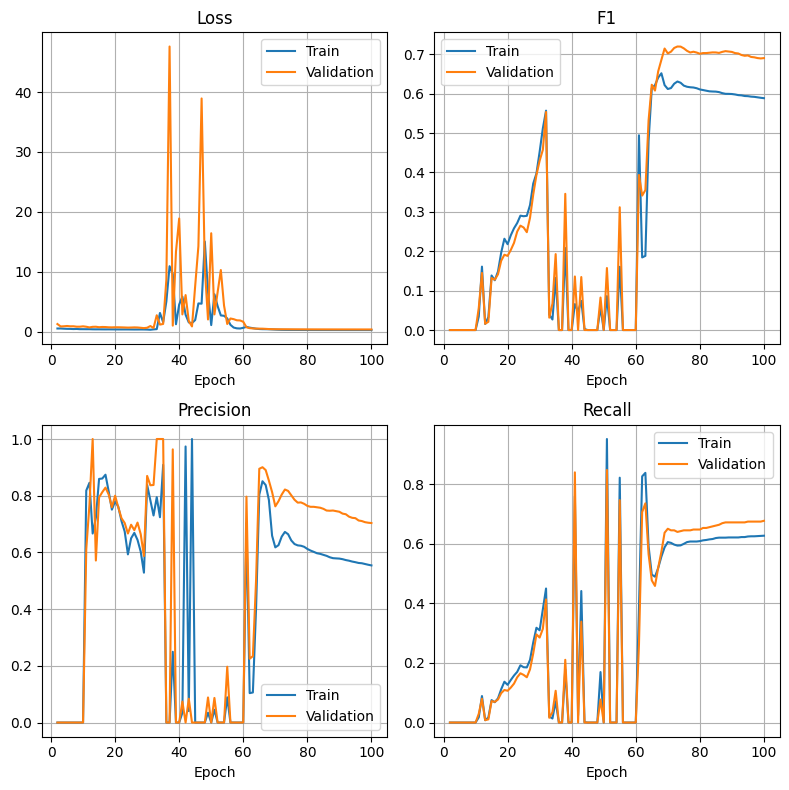

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

plt.sca(axs[0, 0])
plt.plot(res["train_loss"], label="Train")
plt.plot(res["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[0, 1])
plt.plot(res["train_f1"], label="Train")
plt.plot(res["val_f1"], label="Validation")
plt.title("F1")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 0])
plt.plot(res["train_precision"], label="Train")
plt.plot(res["val_precision"], label="Validation")
plt.title("Precision")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 1])
plt.plot(res["train_recall"], label="Train")
plt.plot(res["val_recall"], label="Validation")
plt.title("Recall")
plt.xlabel("Epoch")
plt.legend()
fig.tight_layout();

In [27]:
model

TransformerAnomalyDetector(
  (front_linear): Linear(in_features=2, out_features=8, bias=True)
  (positional_encoder): Identity()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): EncoderBlock(
        (self_attn): MultiheadAttention(
          (query_mat): Linear(in_features=8, out_features=8, bias=False)
          (key_mat): Linear(in_features=8, out_features=8, bias=False)
          (value_mat): Linear(in_features=8, out_features=8, bias=False)
          (o_proj): Linear(in_features=8, out_features=8, bias=True)
        )
        (linear_net): Sequential(
          (0): Linear(in_features=8, out_features=16, bias=True)
          (1): Dropout(p=0.0, inplace=False)
          (2): ReLU(inplace=True)
          (3): Linear(in_features=16, out_features=8, bias=True)
        )
        (norm1): Identity()
        (norm2): Identity()
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (final_linear): Linear(in_features=8, out_features=1, bias=

### export model weights

In [28]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model's state_dict:
front_linear.weight 	 torch.Size([8, 2])
front_linear.bias 	 torch.Size([8])
transformer_encoder.layers.0.self_attn.query_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.key_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.value_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.o_proj.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.o_proj.bias 	 torch.Size([8])
transformer_encoder.layers.0.linear_net.0.weight 	 torch.Size([16, 8])
transformer_encoder.layers.0.linear_net.0.bias 	 torch.Size([16])
transformer_encoder.layers.0.linear_net.3.weight 	 torch.Size([8, 16])
transformer_encoder.layers.0.linear_net.3.bias 	 torch.Size([8])
final_linear.weight 	 torch.Size([1, 8])
final_linear.bias 	 torch.Size([1])
loss_fn.pos_weight 	 torch.Size([])


https://stackoverflow.com/questions/2117313/initializing-constant-static-array-in-header-file

In [29]:
# template_params = 'const static char %s[];'
# with open('../vitis_hls/transformer/scaled_dp_params.h', 'w') as f:
#     for name, param in model.named_parameters():
#         n = name.upper()
#         # s = n.split('.')
#         n = n.replace('.', '_')
#         # p = [f'{x:.6f}' for x in param.ravel().detach().numpy()]
#         # p = ', '.join(p)
#         print(template_params % (n), file=f)

In [30]:
template_params = 'inline constexpr static double %s[%s] = {%s};'
with open('../vitis_hls/transformer/scaled_dp_params.h', 'w') as f:
    for name, param in model.named_parameters():
        n = name.upper()
        # s = param.size()
        n = n.replace('.', '_')
        p = [f'{x:.6f}' for x in param.ravel().detach().numpy()]
        l = len(p)
        p = ', '.join(p)
        print(template_params % (n, l, p), file=f)

In [31]:
xx = torch.tensor([[
    [-1, -1],
    [-1, 0],
    [-1, 1],
    [0, -1],
    [0, 0],
    [0, 1],
    [1, -1],
    [1, 1],
]]).float()
model(xx)

tensor([-29.0613], grad_fn=<SelectBackward0>)

In [32]:
xx.shape

torch.Size([1, 8, 2])

In [33]:
x.shape

torch.Size([46471, 8, 2])

In [34]:
model.front_linear.bias

Parameter containing:
tensor([-0.8888, -0.5915, -0.4813,  2.1828, -0.2624, -1.3615,  0.2901, -0.8199],
       requires_grad=True)

In [35]:
model.front_linear.state_dict()['weight'].shape

torch.Size([8, 2])

In [36]:
yy = model.front_linear(xx)
print(yy)

tensor([[[-3.5625,  2.2752, -1.4784,  1.3720, -0.3577, -1.5561, -1.4979,
          -1.1249],
         [-3.6542,  2.7366, -1.5422,  1.1890, -0.1380, -0.8658, -1.5591,
          -1.5063],
         [-3.7460,  3.1979, -1.6061,  1.0059,  0.0818, -0.1756, -1.6203,
          -1.8876],
         [-0.7970, -1.0529, -0.4175,  2.3659, -0.4821, -2.0518,  0.3512,
          -0.4386],
         [-0.8888, -0.5915, -0.4813,  2.1828, -0.2624, -1.3615,  0.2901,
          -0.8199],
         [-0.9805, -0.1302, -0.5451,  1.9998, -0.0426, -0.6712,  0.2289,
          -1.2013],
         [ 1.9685, -4.3810,  0.6435,  3.3597, -0.6065, -2.5474,  2.2004,
           0.2477],
         [ 1.7849, -3.4583,  0.5158,  2.9936, -0.1670, -1.1669,  2.0781,
          -0.5149]]], grad_fn=<ViewBackward0>)


done

In [38]:
attn = model.transformer_encoder.layers[0].self_attn
q_raw = attn.query_mat(yy)
k_raw = attn.key_mat(yy)
v_raw = attn.value_mat(yy)

qkv = torch.cat([q_raw, k_raw, v_raw], dim=-1)
print(qkv.shape, qkv)

torch.Size([1, 8, 24]) tensor([[[-1.5743e+01, -2.4426e+01,  1.6283e+01, -2.1639e+01,  1.3099e+01,
          -5.1822e+00,  1.5227e+01, -1.3875e+00,  4.1826e+01,  2.0933e+01,
          -3.2712e+01,  3.9530e+01, -3.7556e+00,  9.1201e+00, -7.2565e+00,
          -3.2066e-01, -3.1480e+00,  9.7612e+00, -5.1529e+00, -8.0867e+00,
           1.8566e+00, -1.0034e+01, -3.2801e+00,  5.4563e+00],
         [-1.7336e+01, -2.5426e+01,  1.7090e+01, -2.2852e+01,  1.3105e+01,
          -3.7856e+00,  1.4441e+01, -3.5122e+00,  5.1088e+01,  2.3263e+01,
          -4.0336e+01,  4.2709e+01, -1.6360e+01, -2.9942e+00, -1.6226e+01,
           9.0759e+00, -1.5070e+00,  1.2917e+01, -5.7366e+00, -6.3616e+00,
           1.7777e+00, -8.5246e+00, -4.3858e+00,  6.4996e+00],
         [-1.8929e+01, -2.6427e+01,  1.7898e+01, -2.4066e+01,  1.3112e+01,
          -2.3891e+00,  1.3655e+01, -5.6368e+00,  6.0349e+01,  2.5593e+01,
          -4.7960e+01,  4.5889e+01, -2.8964e+01, -1.5109e+01, -2.5195e+01,
           1.8472e+01,  1.

In [39]:
#qkv = model.transformer_encoder.layers[0].self_attn.qkv_proj(yy)
#print(qkv.shape, qkv)

done

In [40]:
qkv.shape

torch.Size([1, 8, 24])

In [41]:
batch_size = 1
seq_length = 8
qkv = qkv.reshape(batch_size, seq_length, 2, 3 * 4)
# print(qkv)
qkv = qkv.permute(0, 2, 1, 3)
print(qkv)
q, k, v = qkv.chunk(3, dim=-1)

tensor([[[[-1.5743e+01, -2.4426e+01,  1.6283e+01, -2.1639e+01,  1.3099e+01,
           -5.1822e+00,  1.5227e+01, -1.3875e+00,  4.1826e+01,  2.0933e+01,
           -3.2712e+01,  3.9530e+01],
          [-1.7336e+01, -2.5426e+01,  1.7090e+01, -2.2852e+01,  1.3105e+01,
           -3.7856e+00,  1.4441e+01, -3.5122e+00,  5.1088e+01,  2.3263e+01,
           -4.0336e+01,  4.2709e+01],
          [-1.8929e+01, -2.6427e+01,  1.7898e+01, -2.4066e+01,  1.3112e+01,
           -2.3891e+00,  1.3655e+01, -5.6368e+00,  6.0349e+01,  2.5593e+01,
           -4.7960e+01,  4.5889e+01],
          [ 1.4325e+01,  1.1711e+01, -1.0731e+01,  1.2679e+01,  1.0937e+01,
            3.8077e+00,  9.9814e+00, -2.7893e+00, -1.7776e+01, -3.3200e+00,
            1.8308e+01, -4.0241e+00],
          [ 1.2732e+01,  1.0710e+01, -9.9237e+00,  1.1465e+01,  1.0944e+01,
            5.2042e+00,  9.1957e+00, -4.9140e+00, -8.5141e+00, -9.9006e-01,
            1.0684e+01, -8.4502e-01],
          [ 1.1139e+01,  9.7095e+00, -9.1164e+00, 

In [42]:
q.shape

torch.Size([1, 2, 8, 4])

In [43]:
q

tensor([[[[-15.7429, -24.4257,  16.2831, -21.6389],
          [-17.3358, -25.4263,  17.0905, -22.8524],
          [-18.9288, -26.4268,  17.8978, -24.0659],
          [ 14.3246,  11.7106, -10.7311,  12.6787],
          [ 12.7316,  10.7101,  -9.9237,  11.4652],
          [ 11.1387,   9.7095,  -9.1164,  10.2517],
          [ 44.3921,  47.8470, -37.7453,  46.9962],
          [ 41.2062,  45.8458, -36.1306,  44.5693]],

         [[ -3.7556,   9.1201,  -7.2565,  -0.3207],
          [-16.3599,  -2.9942, -16.2259,   9.0759],
          [-28.9643, -15.1085, -25.1952,  18.4725],
          [ 41.9963,  42.1066,  31.7430, -32.3900],
          [ 29.3919,  29.9923,  22.7737, -22.9934],
          [ 16.7876,  17.8779,  13.8043, -13.5969],
          [ 87.7482,  75.0930,  70.7425, -64.4593],
          [ 62.5394,  50.8644,  52.8039, -45.6662]]]],
       grad_fn=<SplitBackward0>)

In [44]:
k

tensor([[[[ 13.0986,  -5.1822,  15.2268,  -1.3875],
          [ 13.1055,  -3.7856,  14.4411,  -3.5122],
          [ 13.1124,  -2.3891,  13.6554,  -5.6368],
          [ 10.9368,   3.8077,   9.9814,  -2.7893],
          [ 10.9436,   5.2042,   9.1957,  -4.9140],
          [ 10.9505,   6.6008,   8.4100,  -7.0386],
          [  8.7749,  12.7976,   4.7360,  -4.1911],
          [  8.7887,  15.5907,   3.1646,  -8.4404]],

         [[ -3.1480,   9.7612,  -5.1529,  -8.0867],
          [ -1.5070,  12.9170,  -5.7366,  -6.3616],
          [  0.1339,  16.0727,  -6.3203,  -4.6366],
          [ -8.5964,  -4.8058,  -1.7174,  -9.6084],
          [ -6.9554,  -1.6500,  -2.3012,  -7.8833],
          [ -5.3145,   1.5057,  -2.8849,  -6.1583],
          [-14.0448, -19.3727,   1.7180, -11.1301],
          [-10.7628, -13.0612,   0.5506,  -7.6800]]]],
       grad_fn=<SplitBackward0>)

In [45]:
v

tensor([[[[ 4.1826e+01,  2.0933e+01, -3.2712e+01,  3.9530e+01],
          [ 5.1088e+01,  2.3263e+01, -4.0336e+01,  4.2709e+01],
          [ 6.0349e+01,  2.5593e+01, -4.7960e+01,  4.5889e+01],
          [-1.7776e+01, -3.3200e+00,  1.8308e+01, -4.0241e+00],
          [-8.5141e+00, -9.9006e-01,  1.0684e+01, -8.4502e-01],
          [ 7.4761e-01,  1.3399e+00,  3.0602e+00,  2.3340e+00],
          [-7.7378e+01, -2.7573e+01,  6.9329e+01, -4.7579e+01],
          [-5.8854e+01, -2.2913e+01,  5.4081e+01, -4.1220e+01]],

         [[ 1.8566e+00, -1.0034e+01, -3.2801e+00,  5.4563e+00],
          [ 1.7777e+00, -8.5246e+00, -4.3858e+00,  6.4996e+00],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00],
          [ 9.1184e-01, -1.0763e+01,  3.5334e+00,  4.0767e-03],
          [ 8.3286e-01, -9.2540e+00,  2.4276e+00,  1.0474e+00],
          [ 7.5388e-01, -7.7448e+00,  1.3219e+00,  2.0907e+00],
          [-3.2968e-02, -1.1493e+01,  1.0347e+01, -5.4482e+00],
          [-1.9092e-01, -8.4742e+00,  

done

In [46]:
import math
import torch.nn.functional as F
d_k = q.size()[-1]
attn_logits = torch.matmul(q, k.transpose(-2, -1))  # [Batch, Head, SeqLen, SeqLen]
attn_logits = attn_logits / math.sqrt(d_k)
attention = F.softmax(attn_logits, dim=-1)  # [Batch, Head, SeqLen, SeqLen]

In [47]:
attn_logits.shape

torch.Size([1, 2, 8, 8])

In [48]:
attn_logits

tensor([[[[  99.1659,   98.6470,   98.1281,  -21.1485,  -21.6674,  -22.1865,
           -141.4630, -142.5009],
          [  98.3145,   98.0634,   97.8122,  -26.0425,  -26.2937,  -26.5448,
           -150.3995, -150.9019],
          [  97.4631,   97.4798,   97.4965,  -30.9365,  -30.9199,  -30.9032,
           -159.3361, -159.3029],
          [ -27.0231,  -28.0500,  -29.0768,   29.3897,   28.3628,   27.3361,
             85.8025,   83.7488],
          [ -27.8746,  -28.6336,  -29.3926,   24.4957,   23.7367,   22.9777,
             76.8659,   75.3479],
          [ -28.7260,  -29.2172,  -29.7084,   19.6017,   19.1105,   18.6193,
             67.9293,   66.9469],
          [-153.2122, -154.7469, -156.2817,   79.9278,   78.3931,   76.8585,
            313.0679,  309.9986],
          [-154.9150, -155.9142, -156.9133,   70.1398,   69.1408,   68.1418,
            295.1947,  293.1966]],

         [[  70.4156,   83.5659,   96.7163,    1.9994,   15.1497,   28.3000,
            -66.4169,  -40.1162],

In [49]:
attention

tensor([[[[5.1299e-01, 3.0531e-01, 1.8170e-01, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [4.1963e-01, 3.2643e-01, 2.5394e-01, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [3.2779e-01, 3.3330e-01, 3.3891e-01, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 2.8043e-25, 1.0043e-25,
           3.5970e-26, 8.8632e-01, 1.1368e-01],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.4786e-23, 6.9217e-24,
           3.2403e-24, 8.2025e-01, 1.7975e-01],
          [7.6791e-43, 4.6943e-43, 2.8727e-43, 7.4723e-22, 4.5722e-22,
           2.7977e-22, 7.2759e-01, 2.7241e-01],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 9.5561e-01, 4.4393e-02],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 8.8060e-01, 1.1940e-01]],

         [[3.7824e-12, 1.9449e-06, 1.0000e+00,

done

In [50]:
values = torch.matmul(attention, v)  # [Batch, Head, SeqLen, Dims]

In [51]:
values.shape

torch.Size([1, 2, 8, 4])

In [52]:
values

tensor([[[[ 4.8019e+01,  2.2491e+01, -3.7810e+01,  4.1656e+01],
          [ 4.9553e+01,  2.2877e+01, -3.9073e+01,  4.2183e+01],
          [ 5.1191e+01,  2.3289e+01, -4.0421e+01,  4.2745e+01],
          [-7.5272e+01, -2.7043e+01,  6.7595e+01, -4.6856e+01],
          [-7.4048e+01, -2.6736e+01,  6.6588e+01, -4.6436e+01],
          [-7.2332e+01, -2.6304e+01,  6.5175e+01, -4.5847e+01],
          [-7.6555e+01, -2.7366e+01,  6.8652e+01, -4.7296e+01],
          [-7.5166e+01, -2.7017e+01,  6.7508e+01, -4.6819e+01]],

         [[ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00],
          [-3.2970e-02, -1.1493e+01,  1.0347e+01, -5.4481e+00],
          [-3.2968e-02, -1.1493e+01,  1.0347e+01, -5.4482e+00],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00],
          [ 1.6987e+00, -7.0154e+00, -

done

In [53]:
values = values.permute(0, 2, 1, 3)  # [Batch, SeqLen, Head, Dims]

In [54]:
values.shape

torch.Size([1, 8, 2, 4])

In [55]:
values

tensor([[[[ 4.8019e+01,  2.2491e+01, -3.7810e+01,  4.1656e+01],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00]],

         [[ 4.9553e+01,  2.2877e+01, -3.9073e+01,  4.2183e+01],
          [-3.2970e-02, -1.1493e+01,  1.0347e+01, -5.4481e+00]],

         [[ 5.1191e+01,  2.3289e+01, -4.0421e+01,  4.2745e+01],
          [-3.2968e-02, -1.1493e+01,  1.0347e+01, -5.4482e+00]],

         [[-7.5272e+01, -2.7043e+01,  6.7595e+01, -4.6856e+01],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00]],

         [[-7.4048e+01, -2.6736e+01,  6.6588e+01, -4.6436e+01],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00]],

         [[-7.2332e+01, -2.6304e+01,  6.5175e+01, -4.5847e+01],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00]],

         [[-7.6555e+01, -2.7366e+01,  6.8652e+01, -4.7296e+01],
          [ 1.6987e+00, -7.0154e+00, -5.4916e+00,  7.5429e+00]],

         [[-7.5166e+01, -2.7017e+01,  6.7508e+01, -4.6819e+01],
          [ 1.6987e+00, -7

done

In [56]:
values = values.reshape(batch_size, 8, 8)  # [Batch, SeqLen, Dims]

In [57]:
values

tensor([[[ 4.8019e+01,  2.2491e+01, -3.7810e+01,  4.1656e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [ 4.9553e+01,  2.2877e+01, -3.9073e+01,  4.2183e+01, -3.2970e-02,
          -1.1493e+01,  1.0347e+01, -5.4481e+00],
         [ 5.1191e+01,  2.3289e+01, -4.0421e+01,  4.2745e+01, -3.2968e-02,
          -1.1493e+01,  1.0347e+01, -5.4482e+00],
         [-7.5272e+01, -2.7043e+01,  6.7595e+01, -4.6856e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.4048e+01, -2.6736e+01,  6.6588e+01, -4.6436e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.2332e+01, -2.6304e+01,  6.5175e+01, -4.5847e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.6555e+01, -2.7366e+01,  6.8652e+01, -4.7296e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.5166e+01, -2.7017e+01,  6.7508e+01, -4.6819e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00]]]

done

In [58]:
np.array([-18.1982, -38.2723, -59.2927,  23.9826,  34.0740, -55.1530,   2.9174,
           43.6071]).dot(np.array([ 0.8812,  1.5822,  3.1899, -1.9023, -0.4501, -2.3163,  2.2023,  0.4510]))

-172.84459199000003

In [59]:
model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()

OrderedDict([('weight',
              tensor([[-0.6571,  0.2426, -0.1920, -0.2658,  2.0994,  1.2701,  2.2648, -1.3922],
                      [ 1.0810, -0.8418, -1.2526,  0.5339,  0.2155, -1.0359,  0.0589, -0.3485],
                      [-0.0773, -0.3560,  1.1136, -1.3488, -0.2224, -0.7706, -2.3350,  2.4590],
                      [-0.1673, -0.4306,  1.9611,  1.3383,  0.1703,  0.9771, -1.3351,  0.8370],
                      [-3.1008, -1.7046,  2.2711, -1.5530, -1.4612, -2.1669, -0.8699,  1.6678],
                      [-0.3796, -0.9711, -1.1727, -0.3947,  0.2912, -0.2011,  0.3986,  0.9045],
                      [ 1.5745,  1.8458, -0.8574,  1.7844,  0.9014,  0.5493,  1.0880, -0.1480],
                      [ 2.0097,  3.1144, -1.9001,  1.2324,  1.3154,  2.4859,  1.1528, -3.3442]])),
             ('bias',
              tensor([-0.2833,  0.6992,  1.5925, -0.5801,  2.6269,  1.4289, -1.0530, -4.0610]))])

In [60]:
model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['weight'].shape

torch.Size([8, 8])

In [62]:
values.shape

torch.Size([1, 8, 8])

In [61]:
torch.matmul(model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['weight'], values.transpose(-1, -2))

tensor([[[-5.8192e+01, -1.4368e+01, -1.5234e+01,  1.4092e+01,  1.3445e+01,
           1.2536e+01,  1.4772e+01,  1.4036e+01],
         [ 1.0726e+02,  1.2018e+02,  1.2359e+02, -1.6361e+02, -1.6106e+02,
          -1.5748e+02, -1.6628e+02, -1.6339e+02],
         [-7.3610e+01, -1.4107e+02, -1.4361e+02,  1.9032e+02,  1.8842e+02,
           1.8577e+02,  1.9230e+02,  1.9015e+02],
         [-2.9040e+01, -6.7923e+01, -7.0265e+01,  1.0117e+02,  9.9420e+01,
           9.6965e+01,  1.0301e+02,  1.0102e+02],
         [-3.0772e+02, -3.4003e+02, -3.4975e+02,  5.3586e+02,  5.2860e+02,
           5.1842e+02,  5.4348e+02,  5.3523e+02],
         [-5.6328e+00, -1.0359e+01, -1.0022e+01,  6.0109e-01,  8.5315e-01,
           1.2067e+00,  3.3674e-01,  6.2291e-01],
         [ 2.1446e+02,  2.3474e+02,  2.4024e+02, -3.1941e+02, -3.1530e+02,
          -3.0954e+02, -3.2372e+02, -3.1905e+02],
         [ 2.4297e+02,  2.9860e+02,  3.0642e+02, -4.6844e+02, -4.6259e+02,
          -4.5438e+02, -4.7457e+02, -4.6793e+02]]]

In [63]:
values

tensor([[[ 4.8019e+01,  2.2491e+01, -3.7810e+01,  4.1656e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [ 4.9553e+01,  2.2877e+01, -3.9073e+01,  4.2183e+01, -3.2970e-02,
          -1.1493e+01,  1.0347e+01, -5.4481e+00],
         [ 5.1191e+01,  2.3289e+01, -4.0421e+01,  4.2745e+01, -3.2968e-02,
          -1.1493e+01,  1.0347e+01, -5.4482e+00],
         [-7.5272e+01, -2.7043e+01,  6.7595e+01, -4.6856e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.4048e+01, -2.6736e+01,  6.6588e+01, -4.6436e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.2332e+01, -2.6304e+01,  6.5175e+01, -4.5847e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.6555e+01, -2.7366e+01,  6.8652e+01, -4.7296e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00],
         [-7.5166e+01, -2.7017e+01,  6.7508e+01, -4.6819e+01,  1.6987e+00,
          -7.0154e+00, -5.4916e+00,  7.5429e+00]]]

In [64]:
model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()

OrderedDict([('weight',
              tensor([[-0.6571,  0.2426, -0.1920, -0.2658,  2.0994,  1.2701,  2.2648, -1.3922],
                      [ 1.0810, -0.8418, -1.2526,  0.5339,  0.2155, -1.0359,  0.0589, -0.3485],
                      [-0.0773, -0.3560,  1.1136, -1.3488, -0.2224, -0.7706, -2.3350,  2.4590],
                      [-0.1673, -0.4306,  1.9611,  1.3383,  0.1703,  0.9771, -1.3351,  0.8370],
                      [-3.1008, -1.7046,  2.2711, -1.5530, -1.4612, -2.1669, -0.8699,  1.6678],
                      [-0.3796, -0.9711, -1.1727, -0.3947,  0.2912, -0.2011,  0.3986,  0.9045],
                      [ 1.5745,  1.8458, -0.8574,  1.7844,  0.9014,  0.5493,  1.0880, -0.1480],
                      [ 2.0097,  3.1144, -1.9001,  1.2324,  1.3154,  2.4859,  1.1528, -3.3442]])),
             ('bias',
              tensor([-0.2833,  0.6992,  1.5925, -0.5801,  2.6269,  1.4289, -1.0530, -4.0610]))])

this layer behaves slightly weird?

In [65]:
W = model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['weight'].detach().numpy()
b = model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['bias'].detach().numpy()
v = values.detach().numpy()[0]
(W@v.T).T + b

array([[ -58.475185 ,  107.95571  ,  -72.01749  ,  -29.619654 ,
        -305.09647  ,   -4.203918 ,  213.40207  ,  238.90852  ],
       [ -14.650979 ,  120.87602  , -139.48192  ,  -68.5027   ,
        -337.4069   ,   -8.930441 ,  233.68552  ,  294.53574  ],
       [ -15.517553 ,  124.28794  , -142.01445  ,  -70.84543  ,
        -347.12088  ,   -8.593195 ,  239.18277  ,  302.36343  ],
       [  13.8090315, -162.90753  ,  191.90916  ,  100.59111  ,
         538.48785  ,    2.0299773, -320.4615   , -472.49997  ],
       [  13.161334 , -160.35762  ,  190.01653  ,   98.8403   ,
         531.22797  ,    2.282022 , -316.3531   , -466.64975  ],
       [  12.252933 , -156.78133  ,  187.36208  ,   96.384796 ,
         521.0458   ,    2.6355338, -310.5909   , -458.44476  ],
       [  14.488345 , -165.5819   ,  193.89415  ,  102.427345 ,
         546.10205  ,    1.7656168, -324.77045  , -478.63562  ],
       [  13.752959 , -162.68678  ,  191.7453   ,  100.43953  ,
         537.8593   ,    2.051791

In [66]:
model.transformer_encoder.layers[0].self_attn.o_proj(values) #- model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['bias']

tensor([[[ -58.4752,  107.9557,  -72.0175,  -29.6196, -305.0965,   -4.2039,
           213.4020,  238.9085],
         [ -14.6510,  120.8760, -139.4819,  -68.5027, -337.4070,   -8.9304,
           233.6855,  294.5357],
         [ -15.5176,  124.2879, -142.0144,  -70.8454, -347.1209,   -8.5932,
           239.1828,  302.3634],
         [  13.8090, -162.9075,  191.9092,  100.5911,  538.4879,    2.0300,
          -320.4615, -472.4999],
         [  13.1613, -160.3577,  190.0165,   98.8403,  531.2280,    2.2820,
          -316.3531, -466.6497],
         [  12.2529, -156.7813,  187.3621,   96.3848,  521.0458,    2.6355,
          -310.5909, -458.4448],
         [  14.4883, -165.5819,  193.8942,  102.4274,  546.1021,    1.7656,
          -324.7704, -478.6356],
         [  13.7530, -162.6868,  191.7453,  100.4395,  537.8593,    2.0518,
          -320.1058, -471.9934]]], grad_fn=<ViewBackward0>)

In [67]:
o_proj = model.transformer_encoder.layers[0].self_attn.o_proj(values)
o_proj = o_proj + yy

In [68]:
o_proj

tensor([[[-6.2038e+01,  1.1023e+02, -7.3496e+01, -2.8248e+01, -3.0545e+02,
          -5.7600e+00,  2.1190e+02,  2.3778e+02],
         [-1.8305e+01,  1.2361e+02, -1.4102e+02, -6.7314e+01, -3.3754e+02,
          -9.7963e+00,  2.3213e+02,  2.9303e+02],
         [-1.9264e+01,  1.2749e+02, -1.4362e+02, -6.9839e+01, -3.4704e+02,
          -8.7687e+00,  2.3756e+02,  3.0048e+02],
         [ 1.3012e+01, -1.6396e+02,  1.9149e+02,  1.0296e+02,  5.3801e+02,
          -2.1774e-02, -3.2011e+02, -4.7294e+02],
         [ 1.2273e+01, -1.6095e+02,  1.8954e+02,  1.0102e+02,  5.3097e+02,
           9.2054e-01, -3.1606e+02, -4.6747e+02],
         [ 1.1272e+01, -1.5691e+02,  1.8682e+02,  9.8385e+01,  5.2100e+02,
           1.9643e+00, -3.1036e+02, -4.5965e+02],
         [ 1.6457e+01, -1.6996e+02,  1.9454e+02,  1.0579e+02,  5.4550e+02,
          -7.8181e-01, -3.2257e+02, -4.7839e+02],
         [ 1.5538e+01, -1.6615e+02,  1.9226e+02,  1.0343e+02,  5.3769e+02,
           8.8489e-01, -3.1803e+02, -4.7251e+02]]]

done

In [69]:
model.transformer_encoder.layers[0].linear_net[0].state_dict()

OrderedDict([('weight',
              tensor([[-0.9778, -0.5007,  1.1806, -1.8607, -2.8670, -0.0199,  1.1510,  1.7639],
                      [ 0.1029,  1.0321, -0.9527,  1.8058, -1.2964, -3.6304,  2.7686,  1.0760],
                      [-0.4769, -1.6353,  0.0814, -0.6185, -1.1887, -1.5840,  1.2516,  0.6675],
                      [ 0.1002,  2.5166, -0.3159,  1.1145, -1.8881, -4.2479,  0.3914,  2.6839],
                      [ 0.8854,  0.0395, -0.6260, -0.6656, -0.5918, -0.4422,  0.7930,  2.0945],
                      [-1.8329, -0.4356, -0.8441, -0.6736, -1.8555, -1.1743,  0.6167,  3.2797],
                      [ 0.0249,  0.1624, -1.2953,  0.3871, -1.1010, -0.7633,  0.8069,  1.0228],
                      [-0.8092, -0.8667, -1.0313,  0.4432, -1.0013, -1.6408, -0.2224,  2.2457],
                      [ 0.5102,  1.2149,  0.4527, -1.1527, -1.2319, -4.5536,  0.6998,  4.2103],
                      [-1.7062, -2.0021, -1.7243,  0.2623,  0.1252, -2.7413,  1.8392,  2.4301],
                

In [70]:
v.T

array([[ 4.8019489e+01,  4.9553246e+01,  5.1190727e+01, -7.5271767e+01,
        -7.4047966e+01, -7.2331566e+01, -7.6555298e+01, -7.5165817e+01],
       [ 2.2491257e+01,  2.2877100e+01,  2.3289040e+01, -2.7043453e+01,
        -2.6735584e+01, -2.6303791e+01, -2.7366348e+01, -2.7016798e+01],
       [-3.7810146e+01, -3.9072723e+01, -4.0420689e+01,  6.7595291e+01,
         6.6587868e+01,  6.5174934e+01,  6.8651878e+01,  6.7508072e+01],
       [ 4.1656292e+01,  4.2182747e+01,  4.2744812e+01, -4.6855743e+01,
        -4.6435673e+01, -4.5846519e+01, -4.7296307e+01, -4.6819370e+01],
       [ 1.6986895e+00, -3.2970272e-02, -3.2968044e-02,  1.6986892e+00,
         1.6986892e+00,  1.6986892e+00,  1.6986892e+00,  1.6986892e+00],
       [-7.0154400e+00, -1.1492595e+01, -1.1492638e+01, -7.0154366e+00,
        -7.0154366e+00, -7.0154366e+00, -7.0154366e+00, -7.0154366e+00],
       [-5.4915795e+00,  1.0346774e+01,  1.0346806e+01, -5.4915814e+00,
        -5.4915814e+00, -5.4915814e+00, -5.4915814e+00, -5

In [71]:
np.array([ 1.8973, -2.5249, -0.6333, -0.3513, -2.1907, -2.9145,  2.7446,  2.0545]).dot(np.array([-180.77614 ,  774.1052  ,  -33.929718,   41.638878,  240.12755 ,
         167.12256 , -605.5751  , -272.7676  ]))

-5526.253415899

In [72]:
W = model.transformer_encoder.layers[0].linear_net[0].state_dict()['weight'].detach().numpy()
b = model.transformer_encoder.layers[0].linear_net[0].state_dict()['bias'].detach().numpy()
v = o_proj.detach().numpy()[0]
(W@v.T) #.T #+ b

array([[ 1510.4299 ,  1666.74   ,  1713.9626 , -2641.2336 , -2606.2598 ,
        -2556.7002 , -2677.1672 , -2638.5505 ],
       [ 1385.825  ,  1569.6136 ,  1603.0658 , -2256.923  , -2232.7239 ,
        -2197.5066 , -2280.1792 , -2255.4475 ],
       [  656.9635 ,   739.6147 ,   756.5205 , -1141.9846 , -1129.9277 ,
        -1112.0968 , -1149.729  , -1138.0184 ],
       [ 1585.2432 ,  1835.019  ,  1878.3499 , -2767.384  , -2735.8657 ,
        -2690.2815 , -2806.4536 , -2773.6306 ],
       [  863.6422 ,  1123.6934 ,  1151.3763 , -1746.1826 , -1725.7926 ,
        -1696.7188 , -1764.6213 , -1742.4943 ],
       [ 1630.8206 ,  1886.0912 ,  1934.2373 , -2930.1494 , -2894.7632 ,
        -2844.183  , -2970.7192 , -2932.5852 ],
       [  855.51587,  1042.3563 ,  1067.0181 , -1568.831  , -1550.6836 ,
        -1524.7792 , -1587.7942 , -1568.1616 ],
       [  820.10266,   983.766  ,  1006.0764 , -1549.8257 , -1533.7922 ,
        -1510.2844 , -1567.2406 , -1551.2295 ],
       [ 1653.5168 ,  2011.219  

v*W^T + b^T

done

In [73]:
model.transformer_encoder.layers[0].linear_net[3].state_dict()

OrderedDict([('weight',
              tensor([[-0.4097,  1.3211, -0.5172, -1.2297, -2.2716, -0.3205,  0.0914,  0.4469,
                       -1.9891,  1.2916, -1.1265, -0.6356,  2.8304,  0.4104,  0.4888, -2.2704],
                      [-1.0983,  1.3166, -2.1049, -2.3243,  0.2283, -1.5792, -0.8986, -0.2640,
                       -0.0032, -0.1648, -0.6086, -0.0570,  2.3263, -0.6811,  0.0671, -0.9932],
                      [ 0.3639, -0.2217,  0.5202, -1.9217,  0.7494,  1.0834, -0.0150,  1.5988,
                       -0.9758,  1.2560, -0.5364,  1.5934, -1.1996,  0.8191, -0.4379,  0.0983],
                      [ 1.5694,  1.2256,  0.0094,  1.2361,  0.2989, -1.3391, -1.0755,  1.2071,
                       -0.8288,  0.2084, -0.5783,  0.2172,  2.7083, -0.8456, -2.9350,  0.3982],
                      [ 0.2101,  1.0863,  0.0153,  1.2378,  1.0931, -0.3288, -0.9979,  2.2568,
                        0.5884, -1.9067,  1.3536,  0.9788, -0.9968, -0.4764, -0.8420,  1.7494],
                     

In [74]:
W = model.transformer_encoder.layers[0].linear_net[3].state_dict()['weight'].detach().numpy()
b = model.transformer_encoder.layers[0].linear_net[3].state_dict()['bias'].detach().numpy()
v = model.transformer_encoder.layers[0].linear_net[0](o_proj).detach().numpy()[0]
(W@v.T).T + b

array([[ -5077.059  ,  -7106.712  ,   -342.1622 ,   2215.9026 ,
          6469.578  ,  -7298.753  ,    298.37793,   2478.165  ],
       [ -6649.267  ,  -8508.454  ,   -524.6324 ,   1635.7408 ,
          7759.647  ,  -9296.232  ,    684.5811 ,   3275.1948 ],
       [ -6841.5913 ,  -8726.688  ,   -535.82275,   1687.5319 ,
          7964.2705 ,  -9524.68   ,    725.19305,   3347.375  ],
       [ 11031.929  ,  13637.411  ,    616.4727 ,  -1938.3412 ,
        -12133.963  ,  14360.893  ,  -1856.1366 ,  -5054.2227 ],
       [ 10889.314  ,  13478.15   ,    607.9925 ,  -1898.3203 ,
        -11982.943  ,  14193.785  ,  -1825.0768 ,  -5002.395  ],
       [ 10687.511  ,  13248.667  ,    596.2859 ,  -1844.2821 ,
        -11768.092  ,  13953.637  ,  -1782.6432 ,  -4926.3315 ],
       [ 11198.803  ,  13822.048  ,    628.4976 ,  -1978.5798 ,
        -12307.623  ,  14518.883  ,  -1939.4752 ,  -5098.5728 ],
       [ 11040.712  ,  13654.372  ,    618.46466,  -1928.6381 ,
        -12142.686  ,  14341.562 

In [75]:
ff2 = model.transformer_encoder.layers[0].linear_net[3](model.transformer_encoder.layers[0].linear_net[0](o_proj))

In [76]:
ff2

tensor([[[ -5077.0586,  -7106.7114,   -342.1623,   2215.9028,   6469.5781,
           -7298.7524,    298.3778,   2478.1650],
         [ -6649.2681,  -8508.4561,   -524.6323,   1635.7405,   7759.6465,
           -9296.2314,    684.5814,   3275.1948],
         [ -6841.5903,  -8726.6895,   -535.8224,   1687.5314,   7964.2705,
           -9524.6797,    725.1932,   3347.3755],
         [ 11031.9287,  13637.4111,    616.4722,  -1938.3407, -12133.9619,
           14360.8916,  -1856.1366,  -5054.2217],
         [ 10889.3154,  13478.1494,    607.9918,  -1898.3195, -11982.9424,
           14193.7861,  -1825.0770,  -5002.3945],
         [ 10687.5107,  13248.6660,    596.2857,  -1844.2828, -11768.0938,
           13953.6367,  -1782.6425,  -4926.3320],
         [ 11198.8018,  13822.0488,    628.4976,  -1978.5787, -12307.6230,
           14518.8828,  -1939.4740,  -5098.5723],
         [ 11040.7139,  13654.3721,    618.4649,  -1928.6383, -12142.6875,
           14341.5605,  -1901.7845,  -5046.9751]]]

done

In [77]:
o = ff2 + o_proj

In [78]:
o

tensor([[[ -5139.0962,  -6996.4805,   -415.6581,   2187.6553,   6164.1240,
           -7304.5122,    510.2819,   2715.9485],
         [ -6667.5732,  -8384.8438,   -665.6564,   1568.4268,   7422.1016,
           -9306.0273,    916.7078,   3568.2241],
         [ -6860.8540,  -8599.2031,   -679.4429,   1617.6919,   7617.2314,
           -9533.4482,    962.7557,   3647.8513],
         [ 11044.9404,  13473.4502,    807.9639,  -1835.3838, -11595.9561,
           14360.8701,  -2176.2468,  -5527.1602],
         [ 10901.5879,  13317.2002,    797.5270,  -1797.2963, -11451.9766,
           14194.7070,  -2141.1401,  -5469.8643],
         [ 10698.7832,  13091.7549,    783.1027,  -1745.8982, -11247.0908,
           13955.6006,  -2093.0044,  -5385.9780],
         [ 11215.2588,  13652.0859,    823.0353,  -1872.7916, -11762.1279,
           14518.1006,  -2262.0439,  -5576.9600],
         [ 11056.2520,  13488.2266,    810.7260,  -1825.2051, -11604.9951,
           14342.4453,  -2219.8123,  -5519.4834]]]

done

In [79]:
o.shape

torch.Size([1, 8, 8])

In [80]:
W = model.final_linear.state_dict()['weight'].detach().numpy()
b = model.final_linear.state_dict()['bias'].detach().numpy()
v = o.detach().numpy()[0]
(W@v.T).T + b

array([[  5446.2773],
       [  8197.694 ],
       [  8407.177 ],
       [-13954.97  ],
       [-13803.021 ],
       [-13582.563 ],
       [-14148.461 ],
       [-13991.716 ]], dtype=float32)

In [81]:
W[0]@(v.T[:, 0])

5448.9434

In [82]:
model.final_linear(o)

tensor([[[  5446.2773],
         [  8197.6953],
         [  8407.1768],
         [-13954.9697],
         [-13803.0205],
         [-13582.5645],
         [-14148.4609],
         [-13991.7158]]], grad_fn=<ViewBackward0>)

In [83]:
model.final_linear(o)[:, 0, 0]

tensor([5446.2773], grad_fn=<SelectBackward0>)

In [84]:
model

TransformerAnomalyDetector(
  (front_linear): Linear(in_features=2, out_features=8, bias=True)
  (positional_encoder): Identity()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): EncoderBlock(
        (self_attn): MultiheadAttention(
          (query_mat): Linear(in_features=8, out_features=8, bias=False)
          (key_mat): Linear(in_features=8, out_features=8, bias=False)
          (value_mat): Linear(in_features=8, out_features=8, bias=False)
          (o_proj): Linear(in_features=8, out_features=8, bias=True)
        )
        (linear_net): Sequential(
          (0): Linear(in_features=8, out_features=16, bias=True)
          (1): Dropout(p=0.0, inplace=False)
          (2): ReLU(inplace=True)
          (3): Linear(in_features=16, out_features=8, bias=True)
        )
        (norm1): Identity()
        (norm2): Identity()
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (final_linear): Linear(in_features=8, out_features=1, bias=

## compare to Linear regression

In [85]:
from src.transformer import LinearRegressionAnomalyDetector

In [86]:
window_size = 8
train_proportion = 0.9
batch_size = 2 * 4096
epochs = 250

In [87]:
seed_everything(1)

tr_dl = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)
va_dl = DataLoader(va_dataset, batch_size=batch_size, shuffle=False)

Global seed set to 1


In [88]:
seed_everything(1)

input_dim = len(tr_cols) * window_size

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5))
# loss_fn = nn.BCEWithLogitsLoss()

model_params = {
    "input_dim": input_dim,
    "learning_rate": 1e-5,
    "loss_fn": loss_fn,
}

model = LinearRegressionAnomalyDetector(
    **model_params,
)

Global seed set to 1


In [89]:
# https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.LearningRateFinder.html#learningratefinder

from lightning.pytorch.callbacks import LearningRateFinder

In [90]:
seed_everything(1)
trainer = pl.Trainer(
    max_epochs=epochs,
    log_every_n_steps=1,
    callbacks=[LearningRateFinder(), MetricTracker()],
)

trainer.fit(model, tr_dl, va_dl)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.13182567385564073
Restoring states from the checkpoint path at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_a9062435-3aab-4fb7-9771-35861dd2f068.ckpt
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_a9062435-3aab-4fb7-9771-35861dd2f068.ckpt

  | Name    | Type              | Params
----------------------------------------------
0 | linear  | Linear            | 17    
1 | loss_fn | BCEWithLogitsLoss | 0     
----------------------------------------------
17        Trainable params
0         Non-trainable params
17        Total params
0.000     Total estimated model params size (MB)
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_a9062435-3aab-4fb7-9771-35861dd2f068.ckpt


Sanity Checking: 0it [00:00, ?it/s]

/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=250` reached.


In [91]:
# %reload_ext tensorboard
# %tensorboard --logdir=lightning_logs/

In [92]:
# dir(trainer)

In [93]:
mt = trainer.callbacks[1]

In [94]:
from copy import deepcopy
res = deepcopy(mt.collection)
for r in res:
    for k, v in r.items():
        if type(v) == torch.Tensor:
            r[k] = np.float32(v.cpu())
        else:
            r[k] = np.float32(v)
res = pd.DataFrame(res)

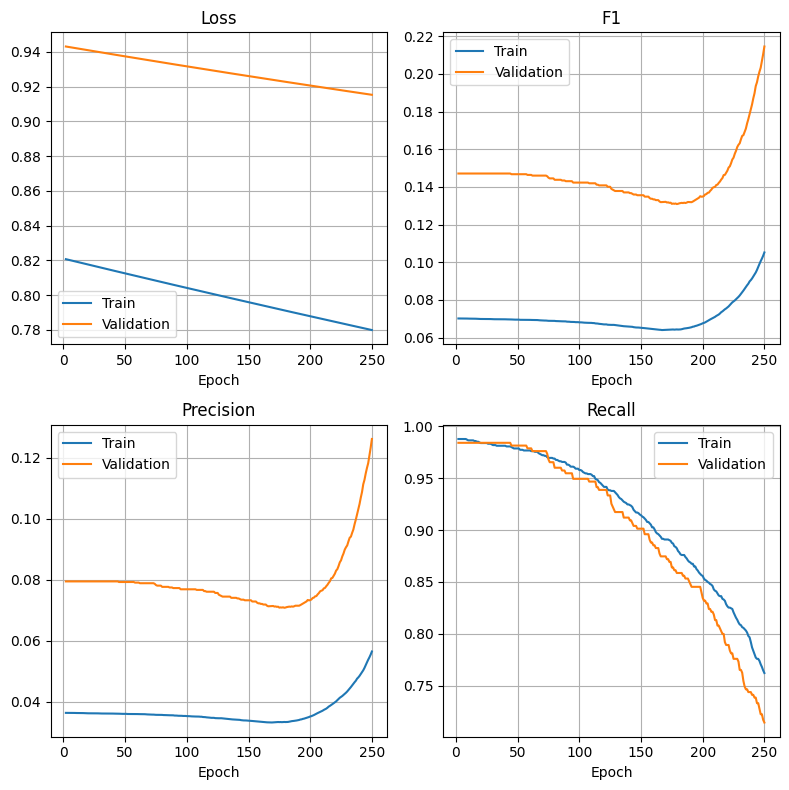

In [95]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

plt.sca(axs[0, 0])
plt.plot(res["train_loss"], label="Train")
plt.plot(res["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[0, 1])
plt.plot(res["train_f1"], label="Train")
plt.plot(res["val_f1"], label="Validation")
plt.title("F1")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 0])
plt.plot(res["train_precision"], label="Train")
plt.plot(res["val_precision"], label="Validation")
plt.title("Precision")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 1])
plt.plot(res["train_recall"], label="Train")
plt.plot(res["val_recall"], label="Validation")
plt.title("Recall")
plt.xlabel("Epoch")
plt.legend()
fig.tight_layout();

slightly worse, but works :)